# Algebraic Loop and PID Sensitivity


## Goal
Study how PID tuning affects stability and control effort when the plant and drive are coupled through a higher-index algebraic loop.

## Model Map
- `SineAngleSetPoint` → `PIDContinuous` → `DriveAdvanced` → `Pendulum`
- Measurement path: `Pendulum.theta` → `AnglePotentiometerADC` → `AnglePotentiometerADCDecoder` → `PIDContinuous`
- Algebraic loop: `theta`, `omega`, `alpha` from pendulum into drive

![System Graph](figures/graphs/03_algebraic_loop_graph.svg)

## Assumptions and Scope
- No wall contact
- Fixed-step co-simulation

## Baseline Parameters
Shared defaults from the Modelica models; used unless explicitly overridden.

In [1]:
import numpy as np

baseline_params = {
    "trajectory": {
        "offset_rad": 0.0,
        "amplitude_rad": np.pi / 9,
        "frequency_hz": 0.25,
        "phase_rad": 0.0,
        "start_time_s": 0.0,
    },
    "pid": {
        "kp": 20,
        "ki": 5,
        "kd": 0.01,
        "td": 0.6,
        "nd": 10,
        "u_min": -1,
        "u_max": 1,
    },
}

baseline_params


{'trajectory': {'offset_rad': 0.0,
  'amplitude_rad': 0.3490658503988659,
  'frequency_hz': 0.25,
  'phase_rad': 0.0,
  'start_time_s': 0.0},
 'pid': {'kp': 20,
  'ki': 5,
  'kd': 0.01,
  'td': 0.6,
  'nd': 10,
  'u_min': -1,
  'u_max': 1}}

## Prerequisites and Setup

In [2]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

from syssimx.components.fmu import FMUComponent
from syssimx.system.connection import Connection
from syssimx import System
from syssimx.viz.system_graph_visualizer import SystemGraphVisualizer


## Discover FMUs

In [3]:
PLATFORM = sys.platform
demo_dir_path = Path().cwd() / "demos" / "ControlledPendulum"
package_path = Path(demo_dir_path / "src/modelica/ControlledPendulum")
fmu_output_dir = Path(demo_dir_path / f"artifacts/fmus/{PLATFORM}")

fmu_paths = {}
for subdir in fmu_output_dir.iterdir():
    if subdir.is_dir():
        fmu_paths[subdir.name] = {}
        for fmu_file in subdir.glob("*.fmu"):
            fmu_paths[subdir.name][fmu_file.stem] = fmu_file
    else:
        fmu_paths[subdir.stem] = subdir


## Instantiate FMU Components

In [4]:
set_point = FMUComponent(name="SineAngle",
                         fmu_path=fmu_paths['Trajectories']["SineAngleSetPoint"],
                         group="Set Point")

pid = FMUComponent(name="PID",
                   fmu_path=fmu_paths['Controllers']["PIDContinuous_cvode"],
                   group="Controller")

drive = FMUComponent(name="Drive",
                     fmu_path=fmu_paths['Actuators']["DriveAdvanced"],
                     group="Actuator")

pendulum = FMUComponent(name="Pendulum",
                        fmu_path=fmu_paths['Plants']["Pendulum_cvode"],
                        group="Plant")

angle_encoder = FMUComponent(name="Angle Sensor",
                             fmu_path=fmu_paths['Sensors']['AnglePotentiometerADC'],
                             group="Encoder")

angle_decoder = FMUComponent(name="Decoder",
                             fmu_path=fmu_paths['Sensors']['AnglePotentiometerADCDecoder'],
                             group="Decoder")


## Apply Baseline Parameters

In [5]:
set_point.set_parameters(
    offset=baseline_params["trajectory"]["offset_rad"],
    amplitude=baseline_params["trajectory"]["amplitude_rad"],
    frequency=baseline_params["trajectory"]["frequency_hz"],
    phase=baseline_params["trajectory"]["phase_rad"],
    startTime=baseline_params["trajectory"]["start_time_s"],
)

pid.set_parameters(
    Kp=baseline_params["pid"]["kp"],
    Ki=baseline_params["pid"]["ki"],
    Kd=baseline_params["pid"]["kd"],
    Td=baseline_params["pid"]["td"],
    Nd=baseline_params["pid"]["nd"],
    uMin=baseline_params["pid"]["u_min"],
    uMax=baseline_params["pid"]["u_max"],
)


## Define Connections

In [6]:
c1 = Connection(
    src_comp=set_point.name,
    src_port=set_point.output_specs["theta_ref"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["theta_ref"].name,
)

c2 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["theta"].name,
    dst_comp=angle_encoder.name,
    dst_port=angle_encoder.input_specs["theta"].name,
)

c3 = Connection(
    src_comp=angle_encoder.name,
    src_port=angle_encoder.output_specs["v_out"].name,
    dst_comp=angle_decoder.name,
    dst_port=angle_decoder.input_specs["v_in"].name,
)

c4 = Connection(
    src_comp=angle_decoder.name,
    src_port=angle_decoder.output_specs["theta"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["theta_meas"].name,
)

c5 = Connection(
    src_comp=pid.name,
    src_port=pid.output_specs["u"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["u_control"].name,
)

c6 = Connection(
    src_comp=drive.name,
    src_port=drive.output_specs["torque"].name,
    dst_comp=pendulum.name,
    dst_port=pendulum.input_specs["tau"].name,
)

c7 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["theta"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["phi"].name,
)

c8 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["omega"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["omega"].name,
)

c9 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["alpha"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["alpha"].name,
)

connections = [c1, c2, c3, c4, c5, c6, c7, c8, c9]
components  = [set_point, pid, drive, pendulum, angle_decoder, angle_encoder]


## Build and Initialize the System

In [7]:
system = System(name="Controlled Pendulum System")

for comp in components:
    system.add_component(comp)

for conn in connections:
    system.add_connection(conn)

system.initialize(t0=0.0)


LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_S

## Visualize the System Graph

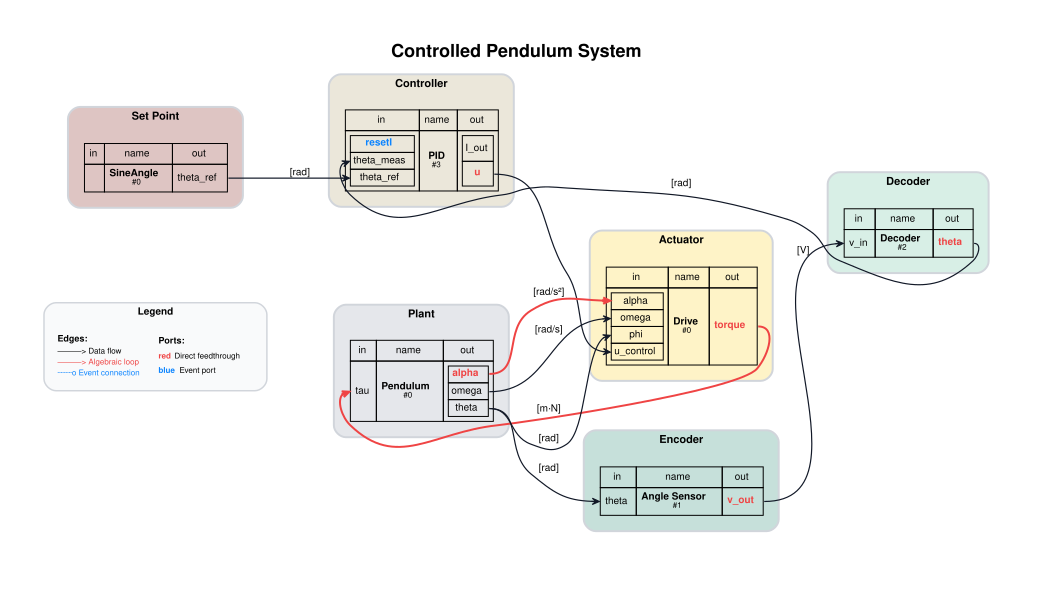

In [8]:
visualizer = SystemGraphVisualizer(system)
visualizer.visualize()

## Experiment Design
We test three PID configurations and compare tracking and control effort.

### Helper: Run a PID Case

In [9]:
def run_pid_case(label: str, kp: float, ki: float, kd: float, dt: float = 0.01, t_end: float = 5.0):
    system.reset()
    pid.set_parameters(Kp=kp, Ki=ki, Kd=kd)

    system.initialize(t0=0.0)
    system.run(0.0, t_end, dt)

    history = system.get_history()

    t_ref, ref_data = history[set_point.name]
    theta_ref = ref_data["theta_ref"]

    t_pend, pend_data = history[pendulum.name]
    theta = pend_data["theta"]

    t_drive, drive_data = history[drive.name]
    torque = drive_data["torque"]

    return {
        "label": label,
        "t_ref": t_ref,
        "theta_ref": theta_ref,
        "t_theta": t_pend,
        "theta": theta,
        "t_torque": t_drive,
        "torque": torque,
        "kp": kp,
        "ki": ki,
        "kd": kd,
    }


## PID Parameter Study

In [10]:
cases = [
    run_pid_case(label="Bad",   kp=20, ki=5, kd=0.01),
    run_pid_case(label="Medium", kp=10, ki=5, kd=0.03),
    run_pid_case(label="Good",  kp=5,  ki=5, kd=0.05),
]

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_S

## Plot: Tracking Performance
Compare pendulum angle against the setpoint for each PID configuration.

In [11]:
palette = {
    "bad": "#d62728",
    "medium": "#ff7f0e",
    "good": "#2ca02c",
    "ref": "#7f7f7f",
}

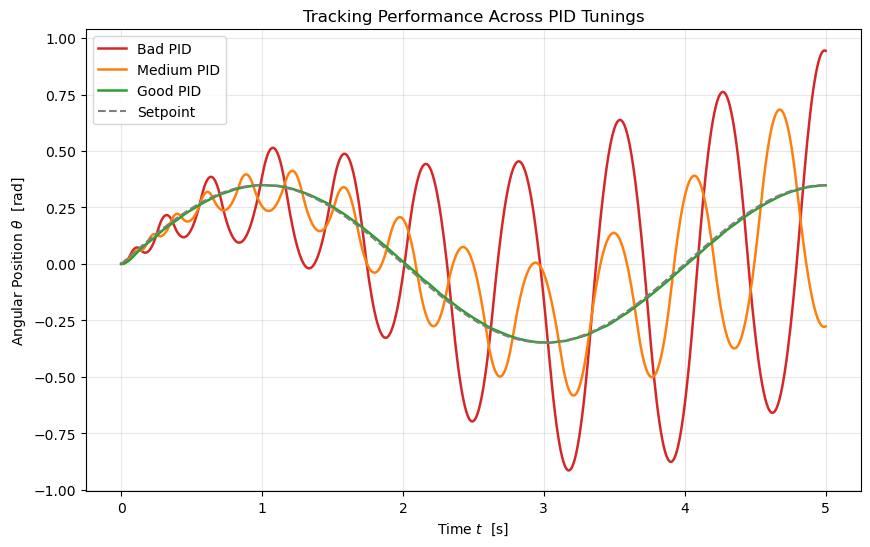

In [12]:
plt.figure(figsize=(10, 6))

for case in cases:
    color = palette[case['label'].lower()]
    plt.plot(case['t_theta'], case['theta'], label=f"{case['label']} PID", color=color, linewidth=1.8)

plt.plot(cases[0]['t_ref'], cases[0]['theta_ref'], label="Setpoint", color=palette["ref"], linestyle="--", linewidth=1.5)
plt.xlabel(r"Time $t$  [s]")
plt.ylabel(r"Angular Position $\theta$  [rad]")
plt.title("Tracking Performance Across PID Tunings")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Plot: Drive Torque
Control effort for each PID configuration.

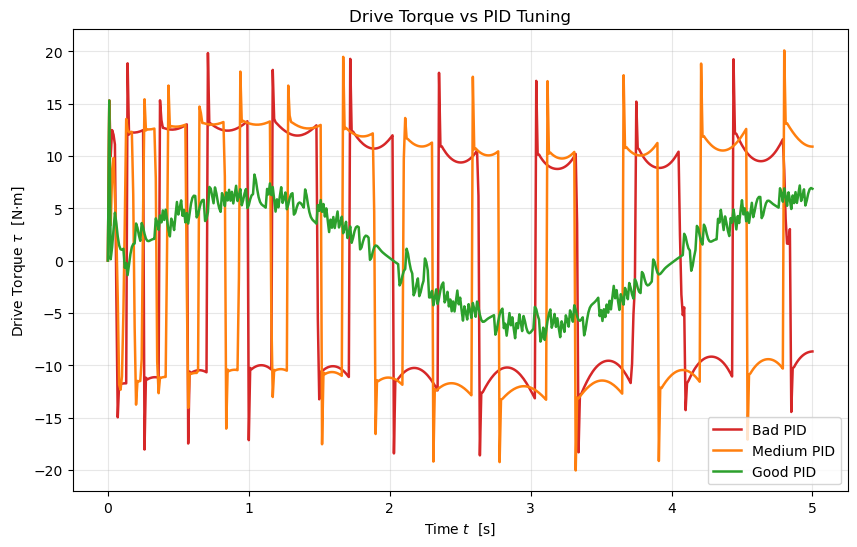

In [13]:
plt.figure(figsize=(10, 6))

for case in cases:
    color = palette[case['label'].lower()]
    plt.plot(case['t_torque'], case['torque'], label=f"{case['label']} PID", color=color, linewidth=1.8)

plt.xlabel(r"Time $t$  [s]")
plt.ylabel(r"Drive Torque $\tau$  [N·m]")
plt.title("Drive Torque vs PID Tuning")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Summary
- We need to adapt the PID parameters to achieve good tracking performance when the drive and pendulum are coupled through an algebraic loop.
- The "Medium" PID configuration shows significant oscillations and poor tracking, while the "Good" configuration achieves much better performance.
- The spikes in the drive torque for the "Medium" case indicate aggressive control actions that may lead to instability, while the "Good" case shows smoother control effort.